In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os 
import napari
import tensorflow as tf 
import tifffile 


from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.segmentation import find_boundaries



In [2]:


DATA_ROOT = Path("C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama")
IMAGE_ROOT = DATA_ROOT / "Nuclear_Scaling/Data_Sets/Control/Extract_3"

Image = IMAGE_ROOT / "Region 1/Droplet 1/Region 1 Droplet 1 .tif"

assert Image.exists(), f"Image not found at {Image}"
MODEL_PATH = DATA_ROOT / "Nuclear_Scaling/Machine_Learning_Models/unet_droplet_nucleus_best_1.2.h5"
assert MODEL_PATH.exists(), f"Model not found at {MODEL_PATH}"
model= tf.keras.models.load_model(MODEL_PATH)
img = tifffile.memmap(Image)  

In [3]:
#### Metadata Interrogation#### 

with tifffile.TiffFile(Image) as tif:
    print("Number of series:", len(tif.series))
    
    for i, s in enumerate(tif.series):
        print(f"\nSeries {i}")
        print("  shape:", s.shape)
        print("  axes: ", s.axes)
        print("  dtype:", s.dtype)


Number of series: 1

Series 0
  shape: (10, 20, 3, 392, 396)
  axes:  TZCYX
  dtype: uint16


In [4]:
viewer = napari.Viewer()
viewer.add_image(img, name="Original Image", colormap="gray", contrast_limits=(0, 255))


<Image layer 'Original Image' at 0x2989702f250>

In [5]:
print(model.input_shape)
print(model.output_shape)

(None, 512, 512, 3)
(None, 512, 512, 3)


In [6]:
import numpy as np

def extract_plane_yxc(img: np.ndarray, t: int, z: int) -> np.ndarray:
    """
    Extract one 2D multichannel plane from TZCYX image data
    and return it as (Y, X, C).
    """
    plane_cyx = img[t, z, :, :, :]          # (C, Y, X)
    plane_yxc = np.moveaxis(plane_cyx, 0, -1)  # (Y, X, C)
    return plane_yxc

In [7]:
plane_yxc = extract_plane_yxc(img, t=9, z=15)
print("Plane shape:", plane_yxc.shape)

Plane shape: (392, 396, 3)


In [8]:
from skimage.transform import resize

def prepare_3channel_image_for_unet(image_yxc: np.ndarray, model):
    """
    Prepare one (Y, X, 3) image for a U-Net expecting (None, 512, 512, 3).
    """
    if image_yxc.ndim != 3:
        raise ValueError(f"Expected (Y, X, C), got {image_yxc.shape}")
    if image_yxc.shape[-1] != 3:
        raise ValueError(f"Expected 3 channels, got {image_yxc.shape[-1]}")

    _, target_h, target_w, target_c = model.input_shape
    if target_c != 3:
        raise ValueError(f"Model expects {target_c} channels")

    original_shape = image_yxc.shape[:2]
    x = image_yxc.astype(np.float32).copy()

    # normalize each channel independently to 0-1
    for c in range(3):
        ch = x[..., c]
        ch_min = ch.min()
        ch_max = ch.max()
        if ch_max > ch_min:
            x[..., c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            x[..., c] = np.zeros_like(ch, dtype=np.float32)

    x_resized = resize(
        x,
        (target_h, target_w, target_c),
        order=1,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True
    ).astype(np.float32)

    x_in = x_resized[None, ...]   # (1, 512, 512, 3)

    return x_in, original_shape, x_resized

In [9]:
NUCLEUS_CLASS_IDX = 2   # change if needed

plane_yxc = extract_plane_yxc(img, t=0, z=0)
x_in, original_shape, x_resized = prepare_3channel_image_for_unet(plane_yxc, model)

pred = model.predict(x_in, verbose=0)

print("Original plane shape:", plane_yxc.shape)
print("Prepared input shape:", x_in.shape)
print("Prediction shape:", pred.shape)

Original plane shape: (392, 396, 3)
Prepared input shape: (1, 512, 512, 3)
Prediction shape: (1, 512, 512, 3)


In [10]:
nucleus_prob_512 = pred[0, ..., NUCLEUS_CLASS_IDX]

print("Nucleus prob shape:", nucleus_prob_512.shape)
print("Range:", nucleus_prob_512.min(), nucleus_prob_512.max())

Nucleus prob shape: (512, 512)
Range: 1.0400861e-14 0.8713268


In [11]:
def resize_prob_map_to_original(prob_map: np.ndarray, original_shape: tuple):
    prob_orig = resize(
        prob_map,
        original_shape,
        order=1,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True
    ).astype(np.float32)
    return prob_orig

nucleus_prob_orig = resize_prob_map_to_original(nucleus_prob_512, original_shape)
nucleus_mask = nucleus_prob_orig >= 0.5

print("Resized nucleus prob shape:", nucleus_prob_orig.shape)
print("Mask pixels:", nucleus_mask.sum())

Resized nucleus prob shape: (392, 396)
Mask pixels: 5566


In [12]:
import numpy as np
from skimage.transform import resize

NUCLEUS_CLASS_IDX = 2  # change if needed

def extract_plane_yxc(img: np.ndarray, t: int, z: int) -> np.ndarray:
    plane_cyx = img[t, z, :, :, :]
    plane_yxc = np.moveaxis(plane_cyx, 0, -1)
    return plane_yxc

def prepare_3channel_image_for_unet(image_yxc: np.ndarray, model):
    if image_yxc.ndim != 3:
        raise ValueError(f"Expected (Y, X, C), got {image_yxc.shape}")
    if image_yxc.shape[-1] != 3:
        raise ValueError(f"Expected 3 channels, got {image_yxc.shape[-1]}")

    _, target_h, target_w, target_c = model.input_shape
    if target_c != 3:
        raise ValueError(f"Model expects {target_c} channels")

    original_shape = image_yxc.shape[:2]
    x = image_yxc.astype(np.float32).copy()

    for c in range(3):
        ch = x[..., c]
        ch_min = ch.min()
        ch_max = ch.max()
        if ch_max > ch_min:
            x[..., c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            x[..., c] = np.zeros_like(ch, dtype=np.float32)

    x_resized = resize(
        x,
        (target_h, target_w, target_c),
        order=1,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True
    ).astype(np.float32)

    x_in = x_resized[None, ...]
    return x_in, original_shape, x_resized

def resize_prob_map_to_original(prob_map: np.ndarray, original_shape: tuple):
    return resize(
        prob_map,
        original_shape,
        order=1,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True
    ).astype(np.float32)

# ---- choose one plane ----
t = 9
z = 15

plane_yxc = extract_plane_yxc(img, t=t, z=z)
print("Extracted plane shape:", plane_yxc.shape)

x_in, original_shape, x_resized = prepare_3channel_image_for_unet(plane_yxc, model)
print("Prepared input shape:", x_in.shape)

pred = model.predict(x_in, verbose=0)
print("Prediction shape:", pred.shape)

nucleus_prob_512 = pred[0, ..., NUCLEUS_CLASS_IDX]
nucleus_prob_orig = resize_prob_map_to_original(nucleus_prob_512, original_shape)

nucleus_mask = nucleus_prob_orig >= 0.5

print("Original shape:", original_shape)
print("Nucleus prob range:", nucleus_prob_orig.min(), nucleus_prob_orig.max())
print("Mask pixels:", nucleus_mask.sum())

Extracted plane shape: (392, 396, 3)
Prepared input shape: (1, 512, 512, 3)
Prediction shape: (1, 512, 512, 3)
Original shape: (392, 396)
Nucleus prob range: 7.659895e-13 0.99919546
Mask pixels: 14226


In [13]:
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label

nucleus_mask = remove_small_holes(nucleus_mask, area_threshold=100)
nucleus_mask = remove_small_objects(nucleus_mask, min_size=100)

lab = label(nucleus_mask)

if lab.max() > 0:
    sizes = [(lab == i).sum() for i in range(1, lab.max() + 1)]
    largest_id = np.argmax(sizes) + 1
    nucleus_mask = lab == largest_id

print("Final mask pixels:", nucleus_mask.sum())

Final mask pixels: 13579


In [16]:
viewer = napari.Viewer()

viewer.add_image(
    plane_yxc,
    name="original_plane",
    channel_axis=2
)

for c in range(pred.shape[-1]):
    prob_map = resize_prob_map_to_original(pred[0, ..., c], original_shape)
    viewer.add_image(
        prob_map,
        name=f"class_{c}_probability"
    )

viewer.add_labels(
    nucleus_mask.astype(int),
    name="predicted_nucleus_mask"
)

<Labels layer 'predicted_nucleus_mask' at 0x15ff7282d10>

Shells Analysis 

In [14]:
from scipy import ndimage as ndi

def compute_signed_distance_map(nucleus_mask: np.ndarray):
    nucleus_mask = nucleus_mask.astype(bool)

    dist_outside = ndi.distance_transform_edt(~nucleus_mask)
    dist_inside  = ndi.distance_transform_edt(nucleus_mask)

    signed_dist = dist_outside.copy()
    signed_dist[nucleus_mask] = -dist_inside[nucleus_mask]

    return signed_dist

signed_dist = compute_signed_distance_map(nucleus_mask)

print("Signed distance range:", signed_dist.min(), signed_dist.max())

Signed distance range: -64.51356446515724 237.26145915424192


In [18]:
viewer = napari.Viewer()

viewer.add_image(
    plane_yxc,
    name="original_plane",
    channel_axis=2
)

viewer.add_labels(
    nucleus_mask.astype(int),
    name="nucleus_mask",
    opacity=0.4
)

viewer.add_image(
    signed_dist,
    name="signed_distance",
    colormap="coolwarm"
)

<Image layer 'signed_distance' at 0x15ffa91ada0>

In [15]:
import pandas as pd
import numpy as np

def make_shells(
    signed_dist,
    shell_width=2,
    max_inside=6,
    max_outside=6
):
    shell_labels = np.zeros_like(signed_dist, dtype=np.int32)

    rows = []
    label_id = 1

    bins = np.arange(-max_inside, max_outside + shell_width, shell_width)

    for d_min, d_max in zip(bins[:-1], bins[1:]):
        mask = (signed_dist >= d_min) & (signed_dist < d_max)

        if np.any(mask):
            shell_labels[mask] = label_id

            rows.append({
                "shell_id": label_id,
                "d_min": d_min,
                "d_max": d_max,
                "location": (
                    "inside" if d_max <= 0 else
                    "outside" if d_min >= 0 else
                    "boundary"
                )
            })

            label_id += 1

    shell_df = pd.DataFrame(rows)
    return shell_labels, shell_df

shell_labels, shell_df = make_shells(
    signed_dist,
    shell_width=2,
    max_inside=6,
    max_outside=6
)

print(shell_df)

   shell_id  d_min  d_max location
0         1     -6     -4   inside
1         2     -4     -2   inside
2         3     -2      0   inside
3         4      0      2  outside
4         5      2      4  outside
5         6      4      6  outside


In [16]:
viewer = napari.Viewer()

viewer.add_image(
    plane_yxc,
    name="original_plane",
    channel_axis=2
)

viewer.add_labels(
    shell_labels,
    name="shell_labels"
)

<Labels layer 'shell_labels' at 0x2990133f9d0>

In [17]:
# Example: use channel 0 for intensity
intensity_image = plane_yxc[..., 1]

In [18]:
def measure_shells(intensity_image, shell_labels, shell_df):
    rows = []

    for shell_id in shell_df["shell_id"]:
        vals = intensity_image[shell_labels == shell_id]

        if vals.size == 0:
            continue

        rows.append({
            "shell_id": shell_id,
            "n_pixels": vals.size,
            "mean_intensity": float(np.mean(vals)),
            "median_intensity": float(np.median(vals)),
            "sum_intensity": float(np.sum(vals)),
            "std_intensity": float(np.std(vals))
        })

    stats = pd.DataFrame(rows)
    return shell_df.merge(stats, on="shell_id", how="left")

shell_stats = measure_shells(intensity_image, shell_labels, shell_df)

print(shell_stats)

   shell_id  d_min  d_max location  n_pixels  mean_intensity  \
0         1     -6     -4   inside       800     1795.068750   
1         2     -4     -2   inside       769     1647.257477   
2         3     -2      0   inside       741     1457.414305   
3         4      0      2  outside       535     1220.844860   
4         5      2      4  outside       934      831.594218   
5         6      4      6  outside       961      377.055151   

   median_intensity  sum_intensity  std_intensity  
0            1797.0      1436055.0      83.461602  
1            1647.0      1266741.0      92.749330  
2            1460.0      1079944.0     100.323591  
3            1220.0       653152.0     107.525299  
4             834.0       776709.0     188.019052  
5             353.0       362350.0     118.062401  


In [19]:
inside_vals = shell_stats[shell_stats["location"] == "inside"]["mean_intensity"].mean()
outside_vals = shell_stats[shell_stats["location"] == "outside"]["mean_intensity"].mean()

print("Inside mean:", inside_vals)
print("Outside mean:", outside_vals)
print("Outside / Inside ratio:", outside_vals / inside_vals)

Inside mean: 1633.2468440788086
Outside mean: 809.8314097043325
Outside / Inside ratio: 0.49584140489253314


In [22]:
import numpy as np
import pandas as pd

def measure_mask_intensity(mask: np.ndarray, intensity_image: np.ndarray) -> dict:
    """
    Measure area and intensity statistics for a binary mask.
    """
    mask = mask.astype(bool)
    vals = intensity_image[mask]

    if vals.size == 0:
        return {
            "area_px": 0,
            "mean_intensity": np.nan,
            "sum_intensity": 0.0,
            "median_intensity": np.nan,
            "std_intensity": np.nan
        }

    return {
        "area_px": int(mask.sum()),
        "mean_intensity": float(vals.mean()),
        "sum_intensity": float(vals.sum()),
        "median_intensity": float(np.median(vals)),
        "std_intensity": float(vals.std())
    }


def compute_ring_from_cumulative_masks(
    inner_mask: np.ndarray,
    outer_mask: np.ndarray,
    intensity_image: np.ndarray
) -> dict:
    """
    Compute ring measurements from two cumulative masks:
    ring = outer_mask minus inner_mask
    """
    inner_mask = inner_mask.astype(bool)
    outer_mask = outer_mask.astype(bool)

    ring_mask = outer_mask & (~inner_mask)
    ring_stats = measure_mask_intensity(ring_mask, intensity_image)

    return {
        "ring_mask": ring_mask,
        **ring_stats
    }


def compute_nc_ratio_from_masks(
    nucleus_mask: np.ndarray,
    h3_mask: np.ndarray,
    h4_mask: np.ndarray,
    intensity_image: np.ndarray
) -> dict:
    """
    Compute nuclear area and N/C ratio using:
    
    N/C = nuclear_mean / mean_intensity_in_ring(H4 - H3)
    """
    nucleus_stats = measure_mask_intensity(nucleus_mask, intensity_image)
    h3_stats = measure_mask_intensity(h3_mask, intensity_image)
    h4_stats = measure_mask_intensity(h4_mask, intensity_image)

    ring_mask = h4_mask.astype(bool) & (~h3_mask.astype(bool))
    ring_stats = measure_mask_intensity(ring_mask, intensity_image)

    nuclear_mean = nucleus_stats["mean_intensity"]
    cyt_mean = ring_stats["mean_intensity"]

    if np.isnan(cyt_mean) or cyt_mean == 0:
        nc_ratio = np.nan
    else:
        nc_ratio = nuclear_mean / cyt_mean

    return {
        "nuclear_area_px": nucleus_stats["area_px"],
        "nuclear_mean_intensity": nucleus_stats["mean_intensity"],
        "nuclear_sum_intensity": nucleus_stats["sum_intensity"],
        "H3_area_px": h3_stats["area_px"],
        "H3_sum_intensity": h3_stats["sum_intensity"],
        "H4_area_px": h4_stats["area_px"],
        "H4_sum_intensity": h4_stats["sum_intensity"],
        "cyto_ring_area_px": ring_stats["area_px"],
        "cyto_ring_mean_intensity": ring_stats["mean_intensity"],
        "cyto_ring_sum_intensity": ring_stats["sum_intensity"],
        "nc_ratio": nc_ratio
    }

In [23]:
results = compute_nc_ratio_from_masks(
    nucleus_mask=nucleus_mask,
    h3_mask=h3_mask,
    h4_mask=h4_mask,
    intensity_image=intensity_image
)

print(pd.Series(results))

NameError: name 'h3_mask' is not defined

In [24]:
import numpy as np
import pandas as pd

def measure_mask(mask: np.ndarray, intensity_image: np.ndarray) -> dict:
    mask = mask.astype(bool)
    vals = intensity_image[mask]

    area_px = int(mask.sum())

    if vals.size == 0:
        return {
            "area_px": area_px,
            "sum_intensity": 0.0,
            "mean_intensity": np.nan,
            "median_intensity": np.nan,
            "std_intensity": np.nan
        }

    return {
        "area_px": area_px,
        "sum_intensity": float(vals.sum()),
        "mean_intensity": float(vals.mean()),
        "median_intensity": float(np.median(vals)),
        "std_intensity": float(vals.std())
    }

In [42]:
def build_cumulative_halos(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    halo_step_px: int = 4,
    n_halos: int = 4,
    valid_outer_mask: np.ndarray | None = None
) -> dict:
    """
    Build cumulative halos equivalent to sequential 4-px expansion in Fiji.

    H1 = nucleus + 4 px
    H2 = nucleus + 8 px
    H3 = nucleus + 12 px
    H4 = nucleus + 16 px
    """
    nucleus_mask = nucleus_mask.astype(bool)

    if valid_outer_mask is None:
        valid_outer_mask = np.ones_like(nucleus_mask, dtype=bool)
    else:
        valid_outer_mask = valid_outer_mask.astype(bool)

    halos = {}
    halo_edges_px = [halo_step_px * i for i in range(1, n_halos + 1)]

    for i, edge in enumerate(halo_edges_px, start=1):
        outer_region = (signed_dist > 0) & (signed_dist <= edge) & valid_outer_mask
        halos[f"H{i}"] = nucleus_mask | outer_region

    return halos

In [44]:
def compute_nc_ratio_cumulative(
    nucleus_mask: np.ndarray,
    h3_mask: np.ndarray,
    h4_mask: np.ndarray,
    intensity_image: np.ndarray
) -> dict:
    """
    Matches the original Fiji/R logic:
    
    cytoplasm_mean = (int_H4 - int_H3) / (area_H4 - area_H3)
    N/C = nuclear_mean / cytoplasm_mean
    """
    nucleus_stats = measure_mask(nucleus_mask, intensity_image)
    h3_stats = measure_mask(h3_mask, intensity_image)
    h4_stats = measure_mask(h4_mask, intensity_image)

    cyto_area_px = h4_stats["area_px"] - h3_stats["area_px"]
    cyto_sum_intensity = h4_stats["sum_intensity"] - h3_stats["sum_intensity"]

    if cyto_area_px <= 0:
        cyto_mean_intensity = np.nan
    else:
        cyto_mean_intensity = cyto_sum_intensity / cyto_area_px

    nuclear_mean_intensity = nucleus_stats["mean_intensity"]

    if np.isnan(cyto_mean_intensity) or cyto_mean_intensity == 0:
        nc_ratio = np.nan
    else:
        nc_ratio = nuclear_mean_intensity / cyto_mean_intensity

    return {
        "nuclear_area_px": nucleus_stats["area_px"],
        "nuclear_sum_intensity": nucleus_stats["sum_intensity"],
        "nuclear_mean_intensity": nucleus_stats["mean_intensity"],
        "H3_area_px": h3_stats["area_px"],
        "H3_sum_intensity": h3_stats["sum_intensity"],
        "H4_area_px": h4_stats["area_px"],
        "H4_sum_intensity": h4_stats["sum_intensity"],
        "cyto_ring_area_px": cyto_area_px,
        "cyto_ring_sum_intensity": cyto_sum_intensity,
        "cyto_ring_mean_intensity": cyto_mean_intensity,
        "nc_ratio": nc_ratio
    }

In [38]:
intensity_image = plane_yxc[..., 1]

In [43]:
halos = build_cumulative_halos(
    nucleus_mask=nucleus_mask,
    signed_dist=signed_dist,
    halo_step_px=4,
    n_halos=4,
    valid_outer_mask=None
)

h1_mask = halos["H1"]
h2_mask = halos["H2"]
h3_mask = halos["H3"]
h4_mask = halos["H4"]

cyto_ring_mask = h4_mask & (~h3_mask)

In [45]:
nc_results = compute_nc_ratio_cumulative(
    nucleus_mask=nucleus_mask,
    h3_mask=h3_mask,
    h4_mask=h4_mask,
    intensity_image=intensity_image
)

print(pd.Series(nc_results))

nuclear_area_px             1.357900e+04
nuclear_sum_intensity       2.880134e+07
nuclear_mean_intensity      2.121020e+03
H3_area_px                  1.884900e+04
H3_sum_intensity            3.107300e+07
H4_area_px                  2.089200e+04
H4_sum_intensity            3.136920e+07
cyto_ring_area_px           2.043000e+03
cyto_ring_sum_intensity     2.962000e+05
cyto_ring_mean_intensity    1.449829e+02
nc_ratio                    1.462946e+01
dtype: float64


In [36]:
cyto_ring_mask = h4_mask & (~h3_mask)

viewer = napari.Viewer()

viewer.add_image(
    plane_yxc,
    name="original_plane",
    channel_axis=2
)

viewer.add_labels(
    nucleus_mask.astype(int),
    name="nucleus_mask",
    opacity=0.4
)

viewer.add_labels(
    h3_mask.astype(int),
    name="H3_cumulative",
    opacity=0.3
)

viewer.add_labels(
    h4_mask.astype(int),
    name="H4_cumulative",
    opacity=0.3
)

viewer.add_labels(
    cyto_ring_mask.astype(int),
    name="H4_minus_H3_ring",
    opacity=0.5
)

<Labels layer 'H4_minus_H3_ring' at 0x299b82b50f0>

In [ ]:
nc_df = pd.DataFrame([nc_results])
print(nc_df)

In [46]:
import numpy as np
import pandas as pd

def measure_mask(mask: np.ndarray, intensity_image: np.ndarray) -> dict:
    """
    Measure area and intensity statistics for a binary mask.
    """
    mask = mask.astype(bool)
    vals = intensity_image[mask]

    area_px = int(mask.sum())

    if vals.size == 0:
        return {
            "area_px": area_px,
            "sum_intensity": 0.0,
            "mean_intensity": np.nan,
            "median_intensity": np.nan,
            "std_intensity": np.nan
        }

    return {
        "area_px": area_px,
        "sum_intensity": float(vals.sum()),
        "mean_intensity": float(vals.mean()),
        "median_intensity": float(np.median(vals)),
        "std_intensity": float(vals.std())
    }

In [47]:
def build_cumulative_halos(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    halo_step_px: int = 4,
    n_halos: int = 4,
    valid_outer_mask: np.ndarray | None = None
) -> dict:
    """
    Build cumulative halos equivalent to sequential 4-px expansion.

    H1 = nucleus + 4 px
    H2 = nucleus + 8 px
    H3 = nucleus + 12 px
    H4 = nucleus + 16 px
    """
    nucleus_mask = nucleus_mask.astype(bool)

    if valid_outer_mask is None:
        valid_outer_mask = np.ones_like(nucleus_mask, dtype=bool)
    else:
        valid_outer_mask = valid_outer_mask.astype(bool)

    halos = {}

    for i in range(1, n_halos + 1):
        edge = halo_step_px * i
        outer_region = (signed_dist > 0) & (signed_dist <= edge) & valid_outer_mask
        halos[f"H{i}"] = nucleus_mask | outer_region

    return halos

In [48]:
def build_halo_measurement_table(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    intensity_image: np.ndarray,
    halo_step_px: int = 4,
    n_halos: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    t: int | None = None,
    z: int | None = None,
    nucleus_id: int | None = None
) -> pd.DataFrame:
    """
    Build a one-row dataframe with cumulative halo measurements and N/C ratio.
    """
    nucleus_mask = nucleus_mask.astype(bool)

    halos = build_cumulative_halos(
        nucleus_mask=nucleus_mask,
        signed_dist=signed_dist,
        halo_step_px=halo_step_px,
        n_halos=n_halos,
        valid_outer_mask=valid_outer_mask
    )

    # nucleus measurements
    nuc_stats = measure_mask(nucleus_mask, intensity_image)

    row = {
        "nuclear_area_px": nuc_stats["area_px"],
        "nuclear_sum_intensity": nuc_stats["sum_intensity"],
        "nuclear_mean_intensity": nuc_stats["mean_intensity"],
        "nuclear_median_intensity": nuc_stats["median_intensity"],
        "nuclear_std_intensity": nuc_stats["std_intensity"]
    }

    # cumulative halo measurements
    halo_stats = {}
    for i in range(1, n_halos + 1):
        stats = measure_mask(halos[f"H{i}"], intensity_image)
        halo_stats[f"H{i}"] = stats

        row[f"H{i}_area_px"] = stats["area_px"]
        row[f"H{i}_sum_intensity"] = stats["sum_intensity"]
        row[f"H{i}_mean_intensity"] = stats["mean_intensity"]
        row[f"H{i}_median_intensity"] = stats["median_intensity"]
        row[f"H{i}_std_intensity"] = stats["std_intensity"]

    # ring measurements between consecutive halos
    for i in range(2, n_halos + 1):
        inner_name = f"H{i-1}"
        outer_name = f"H{i}"

        ring_area = halo_stats[outer_name]["area_px"] - halo_stats[inner_name]["area_px"]
        ring_sum = halo_stats[outer_name]["sum_intensity"] - halo_stats[inner_name]["sum_intensity"]

        if ring_area > 0:
            ring_mean = ring_sum / ring_area
        else:
            ring_mean = np.nan

        row[f"{outer_name}_minus_{inner_name}_area_px"] = ring_area
        row[f"{outer_name}_minus_{inner_name}_sum_intensity"] = ring_sum
        row[f"{outer_name}_minus_{inner_name}_mean_intensity"] = ring_mean

    # specific H4-H3 N/C ratio
    if n_halos >= 4:
        cyto_area = row["H4_area_px"] - row["H3_area_px"]
        cyto_sum = row["H4_sum_intensity"] - row["H3_sum_intensity"]

        if cyto_area > 0:
            cyto_mean = cyto_sum / cyto_area
        else:
            cyto_mean = np.nan

        row["cyto_ring_area_px"] = cyto_area
        row["cyto_ring_sum_intensity"] = cyto_sum
        row["cyto_ring_mean_intensity"] = cyto_mean

        if not np.isnan(cyto_mean) and cyto_mean != 0:
            row["nc_ratio"] = row["nuclear_mean_intensity"] / cyto_mean
        else:
            row["nc_ratio"] = np.nan

    # optional identifiers
    if t is not None:
        row["t"] = t
    if z is not None:
        row["z"] = z
    if nucleus_id is not None:
        row["nucleus_id"] = nucleus_id

    return pd.DataFrame([row])

In [49]:
intensity_image = plane_yxc[..., 1]

halo_table = build_halo_measurement_table(
    nucleus_mask=nucleus_mask,
    signed_dist=signed_dist,
    intensity_image=intensity_image,
    halo_step_px=4,
    n_halos=4,
    valid_outer_mask=None,
    t=0,
    z=0,
    nucleus_id=1
)

print(halo_table.T)

                                       0
nuclear_area_px             1.357900e+04
nuclear_sum_intensity       2.880134e+07
nuclear_mean_intensity      2.121020e+03
nuclear_median_intensity    2.181000e+03
nuclear_std_intensity       2.792844e+02
H1_area_px                  1.517300e+04
H1_sum_intensity            3.029599e+07
H1_mean_intensity           1.996704e+03
H1_median_intensity         2.142000e+03
H1_std_intensity            4.572419e+02
H2_area_px                  1.698200e+04
H2_sum_intensity            3.078546e+07
H2_mean_intensity           1.812829e+03
H2_median_intensity         2.095000e+03
H2_std_intensity            6.867956e+02
H3_area_px                  1.884900e+04
H3_sum_intensity            3.107300e+07
H3_mean_intensity           1.648522e+03
H3_median_intensity         2.034000e+03
H3_std_intensity            8.188688e+02
H4_area_px                  2.089200e+04
H4_sum_intensity            3.136920e+07
H4_mean_intensity           1.501493e+03
H4_median_intens

Full Pipeline

In [51]:
def extract_plane_yxc(img: np.ndarray, t: int, z: int) -> np.ndarray:
    """
    Extract one plane from TZCYX image and return YXC.
    """
    plane_cyx = img[t, z, :, :, :]
    plane_yxc = np.moveaxis(plane_cyx, 0, -1)
    return plane_yxc


def prepare_3channel_image_for_unet(image_yxc: np.ndarray, model):
    """
    Prepare one (Y, X, 3) image for a U-Net expecting (None, 512, 512, 3).
    """
    if image_yxc.ndim != 3:
        raise ValueError(f"Expected (Y, X, C), got {image_yxc.shape}")
    if image_yxc.shape[-1] != 3:
        raise ValueError(f"Expected 3 channels, got {image_yxc.shape[-1]}")

    _, target_h, target_w, target_c = model.input_shape
    if target_c != 3:
        raise ValueError(f"Model expects {target_c} channels")

    original_shape = image_yxc.shape[:2]
    x = image_yxc.astype(np.float32).copy()

    for c in range(3):
        ch = x[..., c]
        ch_min = ch.min()
        ch_max = ch.max()
        if ch_max > ch_min:
            x[..., c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            x[..., c] = np.zeros_like(ch, dtype=np.float32)

    x_resized = resize(
        x,
        (target_h, target_w, target_c),
        order=1,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True
    ).astype(np.float32)

    x_in = x_resized[None, ...]
    return x_in, original_shape


def resize_prob_map_to_original(prob_map: np.ndarray, original_shape: tuple):
    return resize(
        prob_map,
        original_shape,
        order=1,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True
    ).astype(np.float32)


def clean_nucleus_mask(
    nucleus_mask: np.ndarray,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    keep_largest: bool = True
) -> np.ndarray:
    """
    Clean binary nucleus mask.
    """
    mask = nucleus_mask.astype(bool)
    mask = remove_small_holes(mask, area_threshold=hole_area_threshold)
    mask = remove_small_objects(mask, min_size=min_area_px)

    if keep_largest:
        lab = label(mask)
        if lab.max() > 0:
            sizes = [(lab == i).sum() for i in range(1, lab.max() + 1)]
            largest_id = np.argmax(sizes) + 1
            mask = lab == largest_id

    return mask


def compute_signed_distance_map(nucleus_mask: np.ndarray) -> np.ndarray:
    """
    Negative inside nucleus, positive outside.
    """
    nucleus_mask = nucleus_mask.astype(bool)

    dist_outside = ndi.distance_transform_edt(~nucleus_mask)
    dist_inside = ndi.distance_transform_edt(nucleus_mask)

    signed_dist = dist_outside.copy()
    signed_dist[nucleus_mask] = -dist_inside[nucleus_mask]

    return signed_dist


def measure_mask(mask: np.ndarray, intensity_image: np.ndarray) -> dict:
    """
    Measure area and intensity stats for a binary mask.
    """
    mask = mask.astype(bool)
    vals = intensity_image[mask]
    area_px = int(mask.sum())

    if vals.size == 0:
        return {
            "area_px": area_px,
            "sum_intensity": 0.0,
            "mean_intensity": np.nan,
            "median_intensity": np.nan,
            "std_intensity": np.nan
        }

    return {
        "area_px": area_px,
        "sum_intensity": float(vals.sum()),
        "mean_intensity": float(vals.mean()),
        "median_intensity": float(np.median(vals)),
        "std_intensity": float(vals.std())
    }


def build_cumulative_halos(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    halo_step_px: int = 4,
    n_halos: int = 4,
    valid_outer_mask: np.ndarray | None = None
) -> dict:
    """
    Sequential 4-px style cumulative halos:
    H1 = +4 px, H2 = +8 px, H3 = +12 px, H4 = +16 px
    """
    nucleus_mask = nucleus_mask.astype(bool)

    if valid_outer_mask is None:
        valid_outer_mask = np.ones_like(nucleus_mask, dtype=bool)
    else:
        valid_outer_mask = valid_outer_mask.astype(bool)

    halos = {}

    for i in range(1, n_halos + 1):
        edge = halo_step_px * i
        outer_region = (signed_dist > 0) & (signed_dist <= edge) & valid_outer_mask
        halos[f"H{i}"] = nucleus_mask | outer_region

    return halos


def build_halo_measurement_table(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    intensity_image: np.ndarray,
    halo_step_px: int = 4,
    n_halos: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    t: int | None = None,
    z: int | None = None,
    nucleus_id: int | None = None
) -> pd.DataFrame:
    """
    Build a one-row dataframe for one nucleus in one plane.
    """
    nucleus_mask = nucleus_mask.astype(bool)

    halos = build_cumulative_halos(
        nucleus_mask=nucleus_mask,
        signed_dist=signed_dist,
        halo_step_px=halo_step_px,
        n_halos=n_halos,
        valid_outer_mask=valid_outer_mask
    )

    nuc_stats = measure_mask(nucleus_mask, intensity_image)

    row = {
        "nuclear_area_px": nuc_stats["area_px"],
        "nuclear_sum_intensity": nuc_stats["sum_intensity"],
        "nuclear_mean_intensity": nuc_stats["mean_intensity"],
        "nuclear_median_intensity": nuc_stats["median_intensity"],
        "nuclear_std_intensity": nuc_stats["std_intensity"]
    }

    halo_stats = {}
    for i in range(1, n_halos + 1):
        stats = measure_mask(halos[f"H{i}"], intensity_image)
        halo_stats[f"H{i}"] = stats

        row[f"H{i}_area_px"] = stats["area_px"]
        row[f"H{i}_sum_intensity"] = stats["sum_intensity"]
        row[f"H{i}_mean_intensity"] = stats["mean_intensity"]
        row[f"H{i}_median_intensity"] = stats["median_intensity"]
        row[f"H{i}_std_intensity"] = stats["std_intensity"]

    for i in range(2, n_halos + 1):
        inner_name = f"H{i-1}"
        outer_name = f"H{i}"

        ring_area = halo_stats[outer_name]["area_px"] - halo_stats[inner_name]["area_px"]
        ring_sum = halo_stats[outer_name]["sum_intensity"] - halo_stats[inner_name]["sum_intensity"]

        row[f"{outer_name}_minus_{inner_name}_area_px"] = ring_area
        row[f"{outer_name}_minus_{inner_name}_sum_intensity"] = ring_sum
        row[f"{outer_name}_minus_{inner_name}_mean_intensity"] = (
            ring_sum / ring_area if ring_area > 0 else np.nan
        )

    if n_halos >= 4:
        cyto_area = row["H4_area_px"] - row["H3_area_px"]
        cyto_sum = row["H4_sum_intensity"] - row["H3_sum_intensity"]
        cyto_mean = cyto_sum / cyto_area if cyto_area > 0 else np.nan

        row["cyto_ring_area_px"] = cyto_area
        row["cyto_ring_sum_intensity"] = cyto_sum
        row["cyto_ring_mean_intensity"] = cyto_mean
        row["nc_ratio"] = (
            row["nuclear_mean_intensity"] / cyto_mean
            if (not np.isnan(cyto_mean) and cyto_mean != 0)
            else np.nan
        )

    if t is not None:
        row["t"] = t
    if z is not None:
        row["z"] = z
    if nucleus_id is not None:
        row["nucleus_id"] = nucleus_id

    return pd.DataFrame([row])

In [81]:
def build_boundary_centered_halos(
    signed_dist: np.ndarray,
    step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None
) -> dict:
    """
    Build halos centered on the nuclear perimeter.

    H1: inside band  (-step, 0]
    H2: perimeter    approx as boundary line / near-zero band
    H3: outer band   (0, step]
    H4: outer band   (step, 2*step]
    
    Also returns cumulative outer halos for compatibility:
    H3_cum: (0, step]
    H4_cum: (0, 2*step]
    """
    if valid_outer_mask is None:
        valid_outer_mask = np.ones_like(signed_dist, dtype=bool)
    else:
        valid_outer_mask = valid_outer_mask.astype(bool)

    halos = {}

    # Inside band
    halos["H1"] = (signed_dist > -step_px) & (signed_dist <= 0)

    # Perimeter approximation
    # For pixel images, exact boundary line is awkward, so use a very narrow band
    halos["H2"] = np.abs(signed_dist) <= 0.5

    # Outside bands
    halos["H3"] = (signed_dist > 0) & (signed_dist <= step_px) & valid_outer_mask
    halos["H4"] = (signed_dist > step_px) & (signed_dist <= 2 * step_px) & valid_outer_mask

    # Cumulative outward halos if you want Fiji-style subtraction
    halos["H3_cum"] = (signed_dist > 0) & (signed_dist <= step_px) & valid_outer_mask
    halos["H4_cum"] = (signed_dist > 0) & (signed_dist <= 2 * step_px) & valid_outer_mask

    return halos

In [82]:
def build_boundary_halo_measurement_table(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    intensity_image: np.ndarray,
    step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    t: int | None = None,
    z: int | None = None,
    nucleus_id: int | None = None
) -> pd.DataFrame:
    nucleus_mask = nucleus_mask.astype(bool)

    halos = build_boundary_centered_halos(
        signed_dist=signed_dist,
        step_px=step_px,
        valid_outer_mask=valid_outer_mask
    )

    nuc_stats = measure_mask(nucleus_mask, intensity_image)
    h1_stats = measure_mask(halos["H1"], intensity_image)
    h2_stats = measure_mask(halos["H2"], intensity_image)
    h3_stats = measure_mask(halos["H3"], intensity_image)
    h4_stats = measure_mask(halos["H4"], intensity_image)
    h3_cum_stats = measure_mask(halos["H3_cum"], intensity_image)
    h4_cum_stats = measure_mask(halos["H4_cum"], intensity_image)

    # Ring between H4 cumulative and H3 cumulative = outer band 4-8 px
    cyto_ring_area = h4_cum_stats["area_px"] - h3_cum_stats["area_px"]
    cyto_ring_sum = h4_cum_stats["sum_intensity"] - h3_cum_stats["sum_intensity"]
    cyto_ring_mean = cyto_ring_sum / cyto_ring_area if cyto_ring_area > 0 else np.nan

    nc_ratio = (
        nuc_stats["mean_intensity"] / cyto_ring_mean
        if (not np.isnan(cyto_ring_mean) and cyto_ring_mean != 0)
        else np.nan
    )

    row = {
        "nuclear_area_px": nuc_stats["area_px"],
        "nuclear_mean_intensity": nuc_stats["mean_intensity"],
        "nuclear_sum_intensity": nuc_stats["sum_intensity"],

        "H1_area_px": h1_stats["area_px"],
        "H1_mean_intensity": h1_stats["mean_intensity"],
        "H1_sum_intensity": h1_stats["sum_intensity"],

        "H2_area_px": h2_stats["area_px"],
        "H2_mean_intensity": h2_stats["mean_intensity"],
        "H2_sum_intensity": h2_stats["sum_intensity"],

        "H3_area_px": h3_stats["area_px"],
        "H3_mean_intensity": h3_stats["mean_intensity"],
        "H3_sum_intensity": h3_stats["sum_intensity"],

        "H4_area_px": h4_stats["area_px"],
        "H4_mean_intensity": h4_stats["mean_intensity"],
        "H4_sum_intensity": h4_stats["sum_intensity"],

        "H3_cum_area_px": h3_cum_stats["area_px"],
        "H3_cum_sum_intensity": h3_cum_stats["sum_intensity"],

        "H4_cum_area_px": h4_cum_stats["area_px"],
        "H4_cum_sum_intensity": h4_cum_stats["sum_intensity"],

        "cyto_ring_area_px": cyto_ring_area,
        "cyto_ring_sum_intensity": cyto_ring_sum,
        "cyto_ring_mean_intensity": cyto_ring_mean,
        "nc_ratio": nc_ratio
    }

    if t is not None:
        row["t"] = t
    if z is not None:
        row["z"] = z
    if nucleus_id is not None:
        row["nucleus_id"] = nucleus_id

    return pd.DataFrame([row])

In [67]:
MIN_AREA = 5000
MAX_AREA = 20000

In [69]:
def analyze_single_plane(
    plane_yxc: np.ndarray,
    model,
    nucleus_class_idx: int,
    intensity_channel_idx: int,
    pred_threshold: float = 0.5,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    halo_step_px: int = 4,
    n_halos: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    min_valid_area_px: int = 5000,
    max_valid_area_px: int = 20000,
    t: int | None = None,
    z: int | None = None
):
    """
    Analyze one plane and return a one-row dataframe plus QC objects.
    """
    x_in, original_shape = prepare_3channel_image_for_unet(plane_yxc, model)
    pred = model.predict(x_in, verbose=0)

    nucleus_prob_512 = pred[0, ..., nucleus_class_idx]
    nucleus_prob_orig = resize_prob_map_to_original(nucleus_prob_512, original_shape)

    nucleus_mask_raw = nucleus_prob_orig >= pred_threshold
    nucleus_mask = clean_nucleus_mask(
        nucleus_mask_raw,
        min_area_px=min_area_px,
        hole_area_threshold=hole_area_threshold,
        keep_largest=True
    )

    empty_row = pd.DataFrame([{
        "t": t,
        "z": z,
        "nucleus_id": 1,
        "nuclear_area_px": 0,
        "nc_ratio": np.nan
    }])

    if nucleus_mask.sum() == 0:
        return {
            "table": empty_row,
            "nucleus_mask": nucleus_mask,
            "nucleus_prob": nucleus_prob_orig,
            "signed_dist": None
        }

    area = nucleus_mask.sum()

    if area < min_valid_area_px or area > max_valid_area_px:
        return {
            "table": empty_row,
            "nucleus_mask": nucleus_mask,
            "nucleus_prob": nucleus_prob_orig,
            "signed_dist": None
        }

    signed_dist = compute_signed_distance_map(nucleus_mask)
    intensity_image = plane_yxc[..., intensity_channel_idx]

    table = build_halo_measurement_table(
        nucleus_mask=nucleus_mask,
        signed_dist=signed_dist,
        intensity_image=intensity_image,
        halo_step_px=halo_step_px,
        n_halos=n_halos,
        valid_outer_mask=valid_outer_mask,
        t=t,
        z=z,
        nucleus_id=1
    )

    return {
        "table": table,
        "nucleus_mask": nucleus_mask,
        "nucleus_prob": nucleus_prob_orig,
        "signed_dist": signed_dist
    }

In [70]:
def analyze_all_tz_planes(
    img: np.ndarray,
    model,
    nucleus_class_idx: int,
    intensity_channel_idx: int,
    pred_threshold: float = 0.5,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    halo_step_px: int = 4,
    n_halos: int = 4
):
    """
    Run the halo/N-C workflow across all T and Z planes.

    Expects img in TZCYX format.
    Returns one combined dataframe.
    """
    n_t, n_z = img.shape[0], img.shape[1]

    all_tables = []

    for t in range(n_t):
        for z in range(n_z):
            print(f"Processing t={t}, z={z}")

            plane_yxc = extract_plane_yxc(img, t=t, z=z)

            res = analyze_single_plane(
    plane_yxc=plane_yxc,
    model=model,
    nucleus_class_idx=nucleus_class_idx,
    intensity_channel_idx=intensity_channel_idx,
    pred_threshold=pred_threshold,
    min_area_px=min_area_px,
    hole_area_threshold=hole_area_threshold,
    halo_step_px=halo_step_px,
    n_halos=n_halos,
    valid_outer_mask=None,
    min_valid_area_px=5000,
    max_valid_area_px=20000,
    t=t,
    z=z
)

            all_tables.append(res["table"])

    results_df = pd.concat(all_tables, ignore_index=True)
    return results_df

In [54]:
NUCLEUS_CLASS_IDX = 2
INTENSITY_CHANNEL_IDX = 1

In [83]:
results_df = analyze_all_tz_planes(
    img=img,
    model=model,
    nucleus_class_idx=NUCLEUS_CLASS_IDX,
    intensity_channel_idx=INTENSITY_CHANNEL_IDX,
    pred_threshold=0.5,
    min_area_px=100,
    hole_area_threshold=100,
    halo_step_px=4,
    n_halos=4
)

print(results_df.head())
print(results_df.shape)

Processing t=0, z=0
Processing t=0, z=1
Processing t=0, z=2
Processing t=0, z=3
Processing t=0, z=4
Processing t=0, z=5
Processing t=0, z=6
Processing t=0, z=7
Processing t=0, z=8
Processing t=0, z=9
Processing t=0, z=10
Processing t=0, z=11
Processing t=0, z=12
Processing t=0, z=13
Processing t=0, z=14
Processing t=0, z=15
Processing t=0, z=16
Processing t=0, z=17
Processing t=0, z=18
Processing t=0, z=19
Processing t=1, z=0
Processing t=1, z=1
Processing t=1, z=2
Processing t=1, z=3
Processing t=1, z=4
Processing t=1, z=5
Processing t=1, z=6
Processing t=1, z=7
Processing t=1, z=8
Processing t=1, z=9
Processing t=1, z=10
Processing t=1, z=11
Processing t=1, z=12
Processing t=1, z=13
Processing t=1, z=14
Processing t=1, z=15
Processing t=1, z=16
Processing t=1, z=17
Processing t=1, z=18
Processing t=1, z=19
Processing t=2, z=0
Processing t=2, z=1
Processing t=2, z=2
Processing t=2, z=3
Processing t=2, z=4
Processing t=2, z=5
Processing t=2, z=6
Processing t=2, z=7
Processing t=2, z=8


In [84]:
print(results_df[["t", "z", "nuclear_area_px", "nc_ratio"]].head(20))

    t   z  nuclear_area_px  nc_ratio
0   0   0             5181  1.238680
1   0   1            10433  1.285963
2   0   2                0       NaN
3   0   3                0       NaN
4   0   4                0       NaN
5   0   5                0       NaN
6   0   6                0       NaN
7   0   7                0       NaN
8   0   8                0       NaN
9   0   9                0       NaN
10  0  10                0       NaN
11  0  11                0       NaN
12  0  12                0       NaN
13  0  13                0       NaN
14  0  14            11662  1.129657
15  0  15                0       NaN
16  0  16             6523  1.156757
17  0  17             5790  1.156822
18  0  18                0       NaN
19  0  19                0       NaN


In [85]:
results_detected = results_df[results_df["nuclear_area_px"] > 0].copy()
print(results_detected.shape)

(90, 41)


In [64]:
MIN_AREA = 5000
MAX_AREA = 20000

In [91]:
time_summary = (
    results_detected
    .groupby("t", as_index=False)
    .agg(
        mean_nc_ratio=("nc_ratio", "mean"),
        mean_nuclear_area_px=("nuclear_area_px", "mean"),
        n_planes=("nc_ratio", "size")
    )
)

print(time_summary)

   t  mean_nc_ratio  mean_nuclear_area_px  n_planes
0  0       1.193576           7917.800000         5
1  1       1.345821          13934.000000         1
2  2       4.290904           5787.800000         5
3  3       5.328464           6639.090909        11
4  4       7.078931           7990.363636        11
5  5       6.890343           8529.916667        12
6  6       7.233425           8832.083333        12
7  7       7.083635           8946.750000        12
8  8       7.922902           9638.181818        11
9  9       8.179800          10014.400000        10


In [87]:
# keep only detected nuclei
plot_df = results_df[results_df["nuclear_area_px"] > 0].copy()

# for each time point, find the row with the largest nuclear area
idx = plot_df.groupby("t")["nuclear_area_px"].idxmax()

largest_area_df = (
    plot_df.loc[idx]
    .sort_values("t")
    .reset_index(drop=True)
)

print(largest_area_df[["t", "z", "nuclear_area_px", "nc_ratio"]])

   t   z  nuclear_area_px   nc_ratio
0  0  14            11662   1.129657
1  1   3            13934   1.345821
2  2   0             7204   1.316803
3  3  11             8584  10.026894
4  4  11            10550  13.777681
5  5  12            12058  15.269624
6  6  13            12982  15.223603
7  7  13            13338  15.612354
8  8  14            13498  15.335133
9  9  15            13579  14.629456


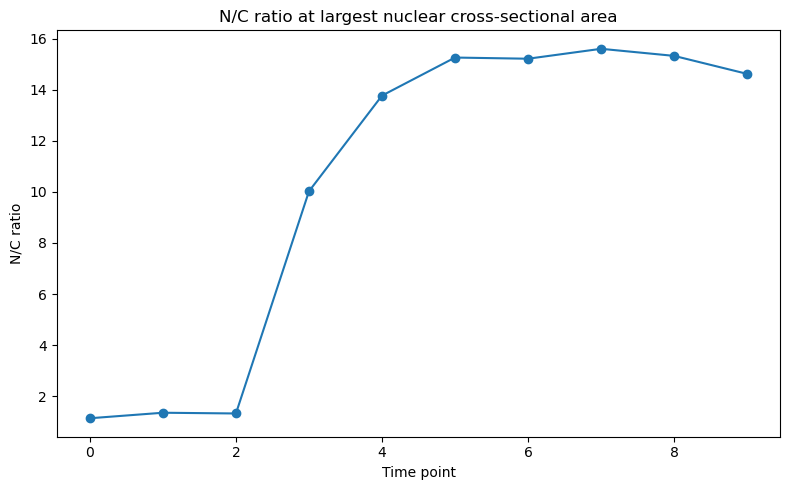

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df["t"],
    largest_area_df["nc_ratio"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio at largest nuclear cross-sectional area")
plt.tight_layout()
plt.show()

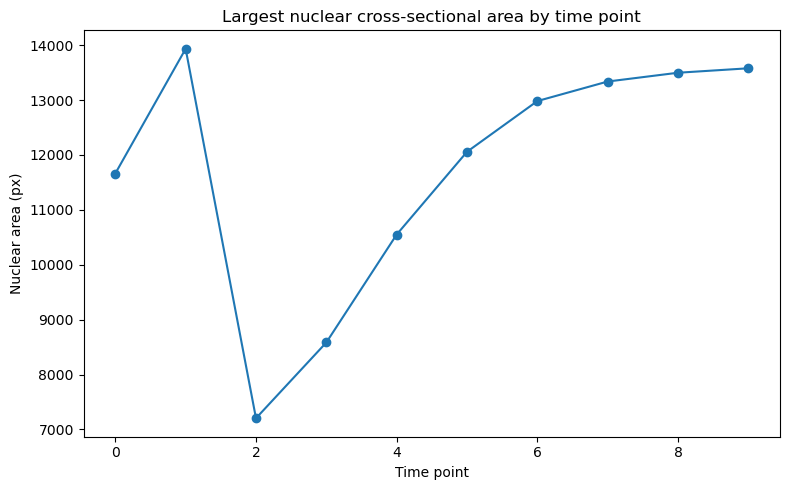

In [90]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df["t"],
    largest_area_df["nuclear_area_px"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Nuclear area (px)")
plt.title("Largest nuclear cross-sectional area by time point")
plt.tight_layout()
plt.show()

In [62]:
print(largest_area_df.columns.tolist())
print(largest_area_df[["t", "z", "nuclear_area_px", "nc_ratio"]])

['nuclear_area_px', 'nuclear_sum_intensity', 'nuclear_mean_intensity', 'nuclear_median_intensity', 'nuclear_std_intensity', 'H1_area_px', 'H1_sum_intensity', 'H1_mean_intensity', 'H1_median_intensity', 'H1_std_intensity', 'H2_area_px', 'H2_sum_intensity', 'H2_mean_intensity', 'H2_median_intensity', 'H2_std_intensity', 'H3_area_px', 'H3_sum_intensity', 'H3_mean_intensity', 'H3_median_intensity', 'H3_std_intensity', 'H4_area_px', 'H4_sum_intensity', 'H4_mean_intensity', 'H4_median_intensity', 'H4_std_intensity', 'H2_minus_H1_area_px', 'H2_minus_H1_sum_intensity', 'H2_minus_H1_mean_intensity', 'H3_minus_H2_area_px', 'H3_minus_H2_sum_intensity', 'H3_minus_H2_mean_intensity', 'H4_minus_H3_area_px', 'H4_minus_H3_sum_intensity', 'H4_minus_H3_mean_intensity', 'cyto_ring_area_px', 'cyto_ring_sum_intensity', 'cyto_ring_mean_intensity', 'nc_ratio', 't', 'z', 'nucleus_id']
   t   z  nuclear_area_px   nc_ratio
0  0   9            57544   2.617603
1  1   2            44086   2.541323
2  2   0       

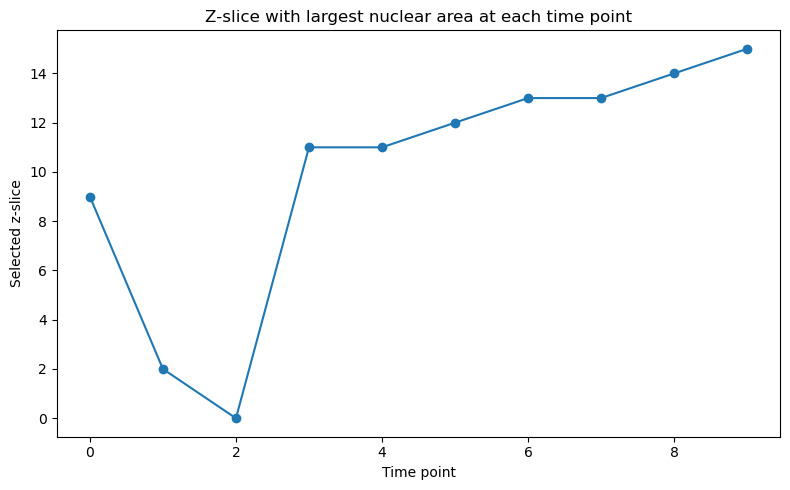

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df["t"],
    largest_area_df["z"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Selected z-slice")
plt.title("Z-slice with largest nuclear area at each time point")
plt.tight_layout()
plt.show()

In [78]:
largest_area_df_filtered = largest_area_df[
    ~largest_area_df["t"].isin([0, 1])
].copy()

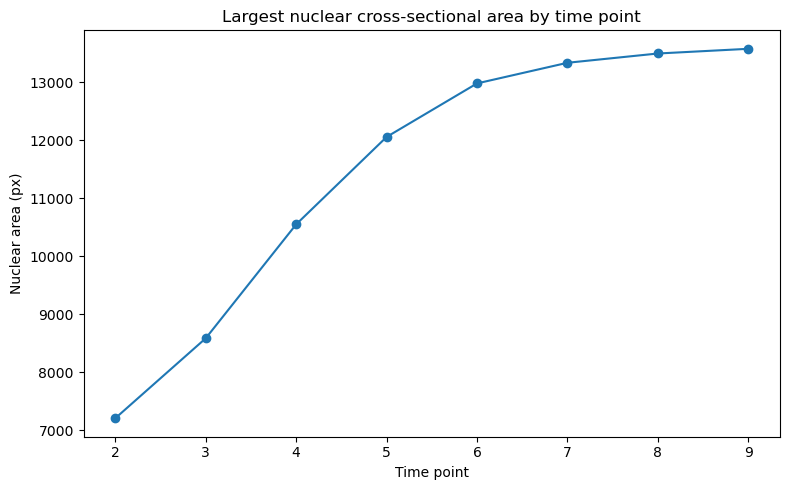

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nuclear_area_px"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Nuclear area (px)")
plt.title("Largest nuclear cross-sectional area by time point")
plt.tight_layout()
plt.show()

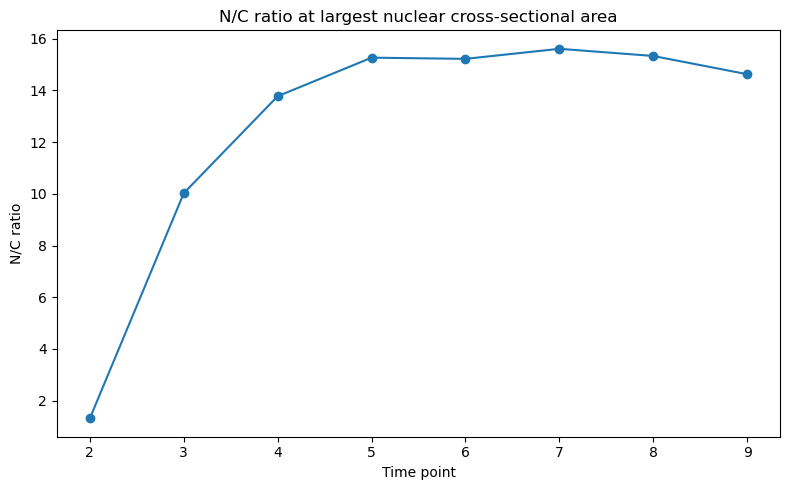

In [80]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio at largest nuclear cross-sectional area")
plt.tight_layout()
plt.show()